Task 2 - Image Deblurring

In [1]:
import os
import cv2
import json
import time
import numpy as np
import matplotlib.pyplot as plt
from skimage import restoration
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

print("All libraries imported!")

All libraries imported!


In [2]:
BLUR_PATH  = '/kaggle/input/datasets/iamravigarg/cocoblur/val2017_blurred_deterministic'
SHARP_PATH = '/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/val2017'
ANNOT_PATH = '/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/annotations'
META_PATH  = '/kaggle/input/datasets/iamravigarg/cocoblur/val2017_blurred_deterministic/blur_metadata.json'

# Load metadata
with open(META_PATH, 'r') as f:
    metadata = json.load(f)

# Get matched image pairs
blur_names  = set(os.listdir(BLUR_PATH))
sharp_names = set(os.listdir(SHARP_PATH))
matched_images = sorted([
    f for f in blur_names.intersection(sharp_names)
    if f.endswith('.jpg')
])

print(f"Total matched pairs: {len(matched_images)}")

Total matched pairs: 5000


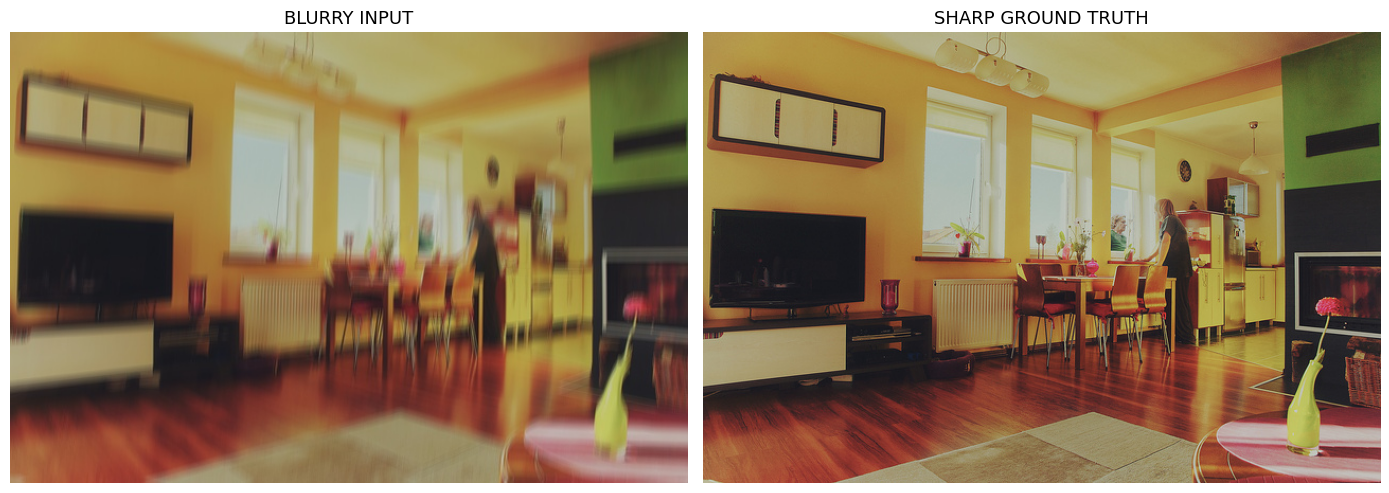

Image: 000000000139.jpg
Size:  (426, 640, 3)


In [3]:
sample = matched_images[0]

blur_img  = cv2.imread(os.path.join(BLUR_PATH, sample))
sharp_img = cv2.imread(os.path.join(SHARP_PATH, sample))

blur_img  = cv2.cvtColor(blur_img,  cv2.COLOR_BGR2RGB)
sharp_img = cv2.cvtColor(sharp_img, cv2.COLOR_BGR2RGB)

# Show side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(blur_img)
axes[0].set_title('BLURRY INPUT', fontsize=13)
axes[0].axis('off')
axes[1].imshow(sharp_img)
axes[1].set_title('SHARP GROUND TRUTH', fontsize=13)
axes[1].axis('off')
plt.tight_layout()
plt.show()

print(f"Image: {sample}")
print(f"Size:  {blur_img.shape}")

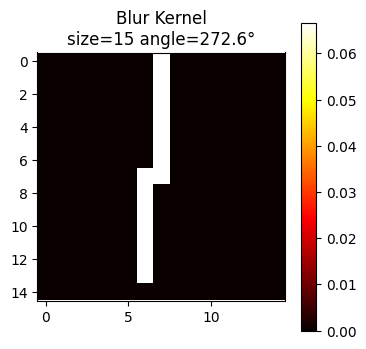

Kernel shape: (15, 15)
Kernel sum:   1.0000


In [4]:
def create_motion_blur_kernel(size, angle):
    """
    Recreate the exact blur kernel used in COCO Blur dataset.
    
    Args:
        size:  kernel size from metadata (7 to 25)
        angle: blur angle in degrees from metadata (0 to 360)
    Returns:
        normalised PSF kernel as numpy array
    """
    kernel = np.zeros((size, size))
    center = size // 2
    angle_rad = np.deg2rad(angle)
    
    for i in range(size):
        offset = i - center
        x = int(center + offset * np.cos(angle_rad))
        y = int(center + offset * np.sin(angle_rad))
        if 0 <= x < size and 0 <= y < size:
            kernel[y, x] = 1
    
    if kernel.sum() > 0:
        kernel = kernel / kernel.sum()
    
    return kernel

# Visualise the kernel for our sample image
params = metadata['transformations'][sample]
kernel = create_motion_blur_kernel(params['size'], params['angle'])

plt.figure(figsize=(4, 4))
plt.imshow(kernel, cmap='hot')
plt.title(f"Blur Kernel\nsize={params['size']} angle={params['angle']:.1f}°")
plt.colorbar()
plt.show()

print(f"Kernel shape: {kernel.shape}")
print(f"Kernel sum:   {kernel.sum():.4f}")

In [5]:
def wiener_deblur(image_path, metadata, balance=0.1):
    """
    Classical Wiener Filter deblurring.
    Uses exact blur kernel from dataset metadata.
    
    Theory:
        Wiener filter minimises mean square error between
        estimated and true image. It requires knowing the
        blur kernel (PSF) and noise level (balance parameter).
        
        Higher balance = more smoothing (less noise, less sharp)
        Lower balance  = more sharpening (more noise, more sharp)
    
    Args:
        image_path: path to blurry image
        metadata:   dataset metadata containing blur parameters
        balance:    regularisation parameter (0.01 to 5.0)
    Returns:
        deblurred image as uint8 numpy array
    """
    filename = os.path.basename(image_path)
    params   = metadata['transformations'][filename]
    
    # Create correct PSF from metadata
    psf = create_motion_blur_kernel(params['size'], params['angle'])
    
    # Read and normalise image
    img       = cv2.imread(image_path)
    img_rgb   = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_float = img_rgb.astype(np.float64) / 255.0
    
    # Apply Wiener filter to each colour channel
    deblurred = np.zeros_like(img_float)
    for i in range(3):
        deblurred[:, :, i] = restoration.wiener(
            img_float[:, :, i],
            psf,
            balance=balance
        )
    
    deblurred = np.clip(deblurred, 0, 1)
    return (deblurred * 255).astype(np.uint8)

print("Wiener filter defined!")

Wiener filter defined!


In [6]:
def richardson_lucy_deblur(image_path, metadata, iterations=30):
    """
    Richardson-Lucy Deconvolution.
    An iterative deblurring algorithm that uses maximum
    likelihood estimation assuming Poisson noise model.
    
    Theory:
        Unlike Wiener which is a single-step calculation,
        Richardson-Lucy iteratively refines the estimate.
        More iterations = sharper but more noise.
        Fewer iterations = smoother but less sharp.
        
        It handles Poisson noise better than Wiener,
        making it suitable for photographic images.
    
    Args:
        image_path: path to blurry image
        metadata:   dataset metadata
        iterations: number of RL iterations (10-50)
    Returns:
        deblurred image as uint8 numpy array
    """
    filename = os.path.basename(image_path)
    params   = metadata['transformations'][filename]
    
    # Create correct PSF
    psf = create_motion_blur_kernel(params['size'], params['angle'])
    
    # Read and normalise
    img       = cv2.imread(image_path)
    img_rgb   = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_float = img_rgb.astype(np.float64) / 255.0
    
    # Apply RL to each channel
    deblurred = np.zeros_like(img_float)
    for i in range(3):
        deblurred[:, :, i] = restoration.richardson_lucy(
            img_float[:, :, i],
            psf,
            num_iter=iterations
        )
    
    deblurred = np.clip(deblurred, 0, 1)
    return (deblurred * 255).astype(np.uint8)

print("Richardson-Lucy defined!")

Richardson-Lucy defined!


In [7]:
sample_blur_path = os.path.join(BLUR_PATH, sample)

# Run both methods
start = time.time()
wiener_result = wiener_deblur(sample_blur_path, metadata, balance=0.1)
wiener_time   = time.time() - start

start = time.time()
rl_result  = richardson_lucy_deblur(sample_blur_path, metadata, iterations=30)
rl_time    = time.time() - start

# Calculate metrics
p_blur   = psnr(sharp_img, blur_img,      data_range=255)
s_blur   = ssim(sharp_img, blur_img,      channel_axis=2, data_range=255)

p_wiener = psnr(sharp_img, wiener_result, data_range=255)
s_wiener = ssim(sharp_img, wiener_result, channel_axis=2, data_range=255)

p_rl     = psnr(sharp_img, rl_result,     data_range=255)
s_rl     = ssim(sharp_img, rl_result,     channel_axis=2, data_range=255)

print("=== RESULTS ON SAMPLE IMAGE ===\n")
print(f"{'Method':<25} {'PSNR':>8} {'SSIM':>8} {'Time':>8}")
print("-" * 55)
print(f"{'Blurry (baseline)':<25} {p_blur:>8.2f} {s_blur:>8.4f} {'N/A':>8}")
print(f"{'Wiener Filter':<25} {p_wiener:>8.2f} {s_wiener:>8.4f} {wiener_time:>7.2f}s")
print(f"{'Richardson-Lucy':<25} {p_rl:>8.2f} {s_rl:>8.4f} {rl_time:>7.2f}s")

=== RESULTS ON SAMPLE IMAGE ===

Method                        PSNR     SSIM     Time
-------------------------------------------------------
Blurry (baseline)            24.98   0.7437      N/A
Wiener Filter                24.31   0.6771    0.24s
Richardson-Lucy              17.82   0.5867    1.92s


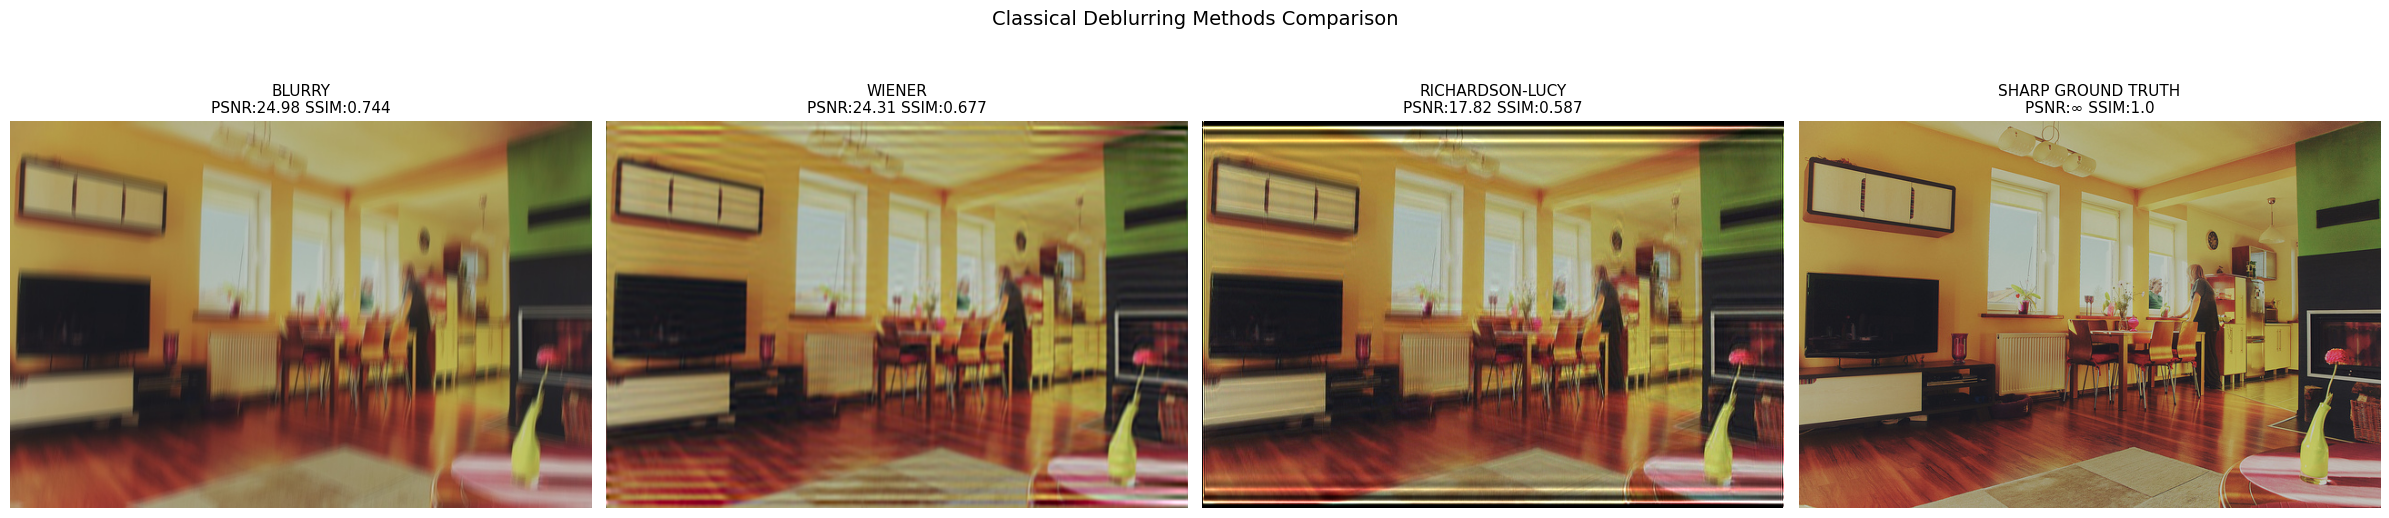

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

axes[0].imshow(blur_img)
axes[0].set_title(f'BLURRY\nPSNR:{p_blur:.2f} SSIM:{s_blur:.3f}', fontsize=11)
axes[0].axis('off')

axes[1].imshow(wiener_result)
axes[1].set_title(f'WIENER\nPSNR:{p_wiener:.2f} SSIM:{s_wiener:.3f}', fontsize=11)
axes[1].axis('off')

axes[2].imshow(rl_result)
axes[2].set_title(f'RICHARDSON-LUCY\nPSNR:{p_rl:.2f} SSIM:{s_rl:.3f}', fontsize=11)
axes[2].axis('off')

axes[3].imshow(sharp_img)
axes[3].set_title('SHARP GROUND TRUTH\nPSNR:∞ SSIM:1.0', fontsize=11)
axes[3].axis('off')

plt.suptitle('Classical Deblurring Methods Comparison', fontsize=14)
plt.tight_layout()
plt.show()

In [4]:
# Find your actual notebook name
!ls /kaggle/working/

comp6001-assignment-1
